# Week 3 Notes

## 3.1 [Churn prediction project](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/01-churn-project.md)

We want to predict the likelihood of a customer churning. Churning means that the customer stops using the product or service. For example a telecom company would like to know which customers are likely to churn to offer them a promotional discount to prevent them from churning. However, it's important to avoid wrong predictions, because:
- If a customer is predicted to churn, but doesn't (**false positive**), the discount would not have been necessary
- If a customer is not predicted to churn, but does (i.e. **false negative**), we lose that customer

We will create a classification model $g$, which will predict $y_i$, which is either 0 (did not churn) or 1 (churned). $g$ will output a continuous number between 0 and 1 (churned) representing the churn likelihood. $i$ refers to the customer.

$$
g(x_i) \approx y_i \quad y_i \in \{0, 1\}
$$

## 3.2 [Data preparation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/02-data-preparation.md)

In [85]:
# data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"
# !wget $data -O data-week-3.csv

In [86]:
import pandas as pd

data = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data)

In [87]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Let's check all the columns:

In [88]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


Let's normalize the columns:

In [89]:
df.columns = (
    df.columns
    .str.replace(" ", "_")
    .str.lower()
)

In [90]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

Let's do the same for the values in `object` columns.

In [91]:
for col in df.select_dtypes(object).columns:
    df[col] = (
        df[col]
        .str.lower()
        .str.replace(" ", "_")
    )

In [92]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


We will clean the data. Columns with 2 values are turned into `boolean` dtypes. Columns with numeric values are turned into numeric dtypes such as `float` and `int`. We use `pd.to_numeric(..., downcast=...)` to downcast to the most memory efficient dtypes while retaining the needed precision.

In [94]:
df = (
    df
    .assign(
        partner=lambda df_: pd.to_numeric((df_.partner=="yes").astype(int), downcast="integer"),
        seniorcitizen=lambda df_: pd.to_numeric(df_.seniorcitizen, downcast="integer"),
        dependents=lambda df_: pd.to_numeric((df_.dependents=="yes").astype(int), downcast="integer"),
        phoneservice=lambda df_: pd.to_numeric((df_.phoneservice=="yes").astype(int), downcast="integer"),
        paperlessbilling=lambda df_: pd.to_numeric((df_.paperlessbilling=="yes").astype(int), downcast="integer"),
        tenure=lambda df_: pd.to_numeric(df_.tenure, downcast="integer"),
        monthlycharges=lambda df_: pd.to_numeric(df_.monthlycharges, downcast="float"),
        totalcharges=lambda df_: pd.to_numeric(df_.totalcharges.replace("_", "0"), errors="coerce", downcast="float"),
        churn=lambda df_: pd.to_numeric((df_.churn=="yes").astype(int), downcast="integer"),
    )
    .astype(
        {
            "customerid": "string",
            "gender": "category",
            "multiplelines": "category",
            "internetservice": "category",
            "onlinesecurity": "category",
            "onlinebackup": "category",
            "deviceprotection": "category",
            "techsupport": "category",
            "streamingtv": "category",
            "streamingmovies": "category",
            "contract": "category",
            "paymentmethod": "category",
        }
    )
)

In [95]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,1,0,0,0,0
dependents,0,0,0,0,0
tenure,1,34,2,45,2
phoneservice,0,1,1,0,1
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerid        7043 non-null   string  
 1   gender            7043 non-null   category
 2   seniorcitizen     7043 non-null   int8    
 3   partner           7043 non-null   int8    
 4   dependents        7043 non-null   int8    
 5   tenure            7043 non-null   int8    
 6   phoneservice      7043 non-null   int8    
 7   multiplelines     7043 non-null   category
 8   internetservice   7043 non-null   category
 9   onlinesecurity    7043 non-null   category
 10  onlinebackup      7043 non-null   category
 11  deviceprotection  7043 non-null   category
 12  techsupport       7043 non-null   category
 13  streamingtv       7043 non-null   category
 14  streamingmovies   7043 non-null   category
 15  contract          7043 non-null   category
 16  paperlessbilling  7043 n

## 3.3 [Setting up the validation framework](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/03-validation.md)


We will split the data into train, validation, and test. Instead of doing it using `numpy`, we will use a popular ML library called `scikit-learn`.

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

We will make a 60-20-20 split again:

In [99]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [100]:
print(df_train.shape[0])
print(df_val.shape[0])
print(df_test.shape[0])

4225
1409
1409


In [101]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [102]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [103]:
y_train

array([0, 0, 1, ..., 1, 0, 1], dtype=int8)

## 3.4 [EDA](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/04-eda.md)


For EDA, we will look at `df_full_train`. So we will not look at `df_test`. Let's start by checking missing values:

In [104]:
df_full_train.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

There are no missing values. Next, let's look at the distribution of our target variable `churn`:

In [105]:
import matplotlib.pyplot as plt

df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [106]:
# Another way to normalize
global_churn_rate = df_full_train.churn.mean().round(2)
global_churn_rate

np.float64(0.27)

There is a churn rate of 27%. 

In [107]:
numeric = ["tenure", "monthlycharges", "totalcharges"]
categorical = df_full_train.drop(columns=["churn", "tenure"]).select_dtypes(include=["category", "int8"]).columns.to_list()

## 3.5 [Feature importance: Churn rate and risk ratio](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/05-risk.md)


We want to look at churn rate for different groups (e.g. based on gender):

In [108]:
(
    df_full_train
    .groupby("gender", observed=True)
    .churn
    .mean()
)

gender
female    0.276824
male      0.263214
Name: churn, dtype: float64

In [109]:
(
    df_full_train
    .groupby("partner", observed=True)
    .churn
    .mean()
)

partner
0    0.329809
1    0.205033
Name: churn, dtype: float64

We see that the churn rate per gender is very close to the global churn rate. On the other hand, the churn rate based on the `partner` feature does differ significantly between having a partner or not. Therefore, the `partner` feature is likely more important than the `gender` feature. We can define a measure of feature importance as the **difference** between the global churn rate and the churn rate per group:

In [110]:
df_full_train.churn.mean() - df_full_train.groupby("gender", observed=True).churn.mean()

gender
female   -0.006856
male      0.006755
Name: churn, dtype: float64

In [111]:
df_full_train.churn.mean() - df_full_train.groupby("partner", observed=True).churn.mean()

partner
0   -0.059841
1    0.064935
Name: churn, dtype: float64

A negative number here means that a certain group is less likely to churn. A positive number means a group is more likely to churn. The magnitude indicates the strength of this relationship. Features can be compared this way.

Alternatively we could **divide** instead of calculating the difference:

In [112]:
df_full_train.churn.mean() / df_full_train.groupby("gender", observed=True).churn.mean()

gender
female    0.975233
male      1.025662
Name: churn, dtype: float64

In [113]:
df_full_train.churn.mean() / df_full_train.groupby("partner", observed=True).churn.mean()

partner
0    0.818559
1    1.316703
Name: churn, dtype: float64

In [114]:
for col in categorical:
    display(
        (
            df_full_train
            .groupby(col, observed=True)
            .churn
            .agg(["mean", "count"])
        )
        .assign(
            diff=lambda df_: df_["mean"] - df_full_train.churn.mean(),
            risk=lambda df_: df_["mean"] / df_full_train.churn.mean()
        )
    )

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


,mean,count,diff,risk
partner,,,,
0,0.329809,2932,0.059841,1.221659
1,0.205033,2702,-0.064935,0.759472


,mean,count,diff,risk
dependents,,,,
0,0.313760,3968,0.043792,1.162212
1,0.165666,1666,-0.104302,0.613651


,mean,count,diff,risk
phoneservice,,,,
0,0.241316,547,-0.028652,0.893870
1,0.273049,5087,0.003081,1.011412


...

,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730


,mean,count,diff,risk
paperlessbilling,,,,
0,0.172071,2313,-0.097897,0.637375
1,0.338151,3321,0.068183,1.252560


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


From the above numbers, we can discern which features will be important for our classification model. However for a large number of features and groups, it becomes intractable. Can we quantify the importance of a feature?

## 3.6 [Feature importance: Mutual information](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/06-mutual-info.md)


Mutual information is a way of measuring the importance of categorical variables. In the previous lesson, we came up with a measure for feature importance. This lesson we will look at **Mutual Information**. This is a concept from Information Theory which measures the mutual dependence between two variables. More specifically, if we observe a feature (e.g. `paymentmethod`), how much do we then know about the target variable (`churn`)?

$$
\mathbf{I}(X;Y) = \sum_{y \in Y} \sum_{x \in X} p_{(X, Y)}(x, y) \log \left( \frac{p_{(X, Y)}(x, y)} {p_{X}(x) p_{Y}(y)} \right)
$$

where: $p_{X, Y}$ is the **joint probability mass function** of $X$ and $Y$, and $p_{X}$ and $p_{Y}$ are the **marginal probability mass functions** of $X$ and $Y$ respectively.

In [115]:
from sklearn.metrics import mutual_info_score

mutual_info_score(df_full_train.churn, df_full_train.contract)

np.float64(0.0983203874041556)

In [116]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

np.float64(0.009967689095399745)

In [117]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

np.float64(0.0001174846211139946)

`contract` seems to be the most important variable for explaining `churn`, followed by `partner`, and then `gender`. Let's apply it to all variables:

In [118]:
df_full_train[categorical].apply(lambda s: mutual_info_score(s, df_full_train.churn)).sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 3.7 [Feature importance: Correlation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/07-correlation.md)


Where **Mutual Information** is used to check the relationship between **categorical variables** and a target variable, the **correlation coefficient** is used to check the relationship between **continuous variables** and a target variable. A value close to 0 indicates a weak correlation and close to 1 or 1- a strong correlation. A negative correlation means an increase in one variable leads to a decrease in the other variable. A positive correlation means both variables move together.

In [119]:
df_full_train[numeric].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

We can see that as `tenure` increases, the likelihood of `churn` decreases. Same goes for `totalcharges`. Of course `totalcharges` is correlated with `tenure`. On the other hand, when `monthlycharges` increases (so not considering how long a customer stayed), `churn` is more likely.

<Axes: xlabel='tenure'>

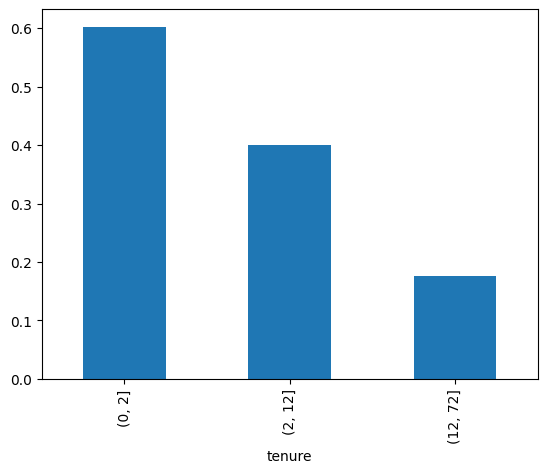

In [120]:
(
    df_full_train
    .groupby(
        by=pd.cut(df_full_train.tenure, bins=[0, 2, 12, 72]),
        observed=True,)["churn"]
    .mean()
    .plot
    .bar()
)

We can see that as tenure increases, churn rate decreases, demonstrating the negative correlation between `tenure` and `churn` we found earlier.

## 3.8 [One-hot encoding](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/08-ohe.md)


**One-hot encoding** is converting a categorical column into multiple columns per category. For example:

In [121]:
df_full_train[["gender", "contract"]]

,gender,contract
0,male,two_year
1,female,one_year
2,male,two_year
3,male,one_year
4,male,one_year
...,...,...
5629,male,month-to-month
5630,male,two_year
5631,male,month-to-month
5632,male,month-to-month


In [122]:
df_encoded = pd.get_dummies(df_full_train[["gender", "contract"]], drop_first=True)
df_encoded

,gender_male,contract_one_year,contract_two_year
0,True,False,True
1,False,True,False
2,True,False,True
3,True,True,False
4,True,True,False
...,...,...,...
5629,True,False,False
5630,True,False,True
5631,True,False,False
5632,True,False,False


We can also use scikit-learn:

In [123]:
from sklearn.feature_extraction import DictVectorizer

First we need to create a dictionary per row of the DataFrame:

In [124]:
dicts = df_full_train[["gender", "contract", "tenure"]].to_dict(orient="records")

We added `tenure` which actually isn't a categorical variable but a numerical one. We will see in a bit why.

In `DictVectorizer` we indicate `sparse` should be `False`. Since one-hot encoding leads to a matrix with many zeros, it is more memory-efficient to store them as sparse matrices (Compressed Sparse Row Matrix). However, we set it to False, to be able to inspect the matrix.

In [125]:
dv = DictVectorizer(sparse=False)
dv.fit(dicts)

DictVectorizer(sparse=False)

In [126]:
dv.transform(dicts)

array([[ 0.,  0.,  1.,  0.,  1., 12.],
       [ 0.,  1.,  0.,  1.,  0., 42.],
       [ 0.,  0.,  1.,  0.,  1., 71.],
       ...,
       [ 1.,  0.,  0.,  0.,  1., 28.],
       [ 1.,  0.,  0.,  0.,  1.,  2.],
       [ 0.,  0.,  1.,  1.,  0., 16.]])

In [127]:
dv.feature_names_

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'gender=female',
 'gender=male',
 'tenure']

We have transformed our DataFrame into a one-hot encoded representation. We can see that `tenure` is left unchanged. DictVectorizer is smart enough to know that a column is numerical and leave it as-is. Let's now do it for all the columns:

In [128]:
dv = DictVectorizer(sparse=False)

train_dicts = df_train[categorical + numeric].to_dict(orient="records")
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numeric].to_dict(orient="records")
X_val = dv.fit_transform(val_dicts)

Now our feature matrices $\mathbf{X}_{\text{train}}$ and $\mathbf{X}_{\text{val}}$ are ready.

## 3.9 [Logistic regression](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/09-logistic-regression.md)


We have a model:
$$
g(x_i) = y_i
$$

$y_i$ can either be:
- regression
- classification
    - **binary** &rarr; This is what **logistic regression** aims to solve
    - multi-class

$$
y_i \in \{0, 1\}
$$

$0$ is negative, e.g. no churn, no spam \
$1$ is positive, e.g. churn, spam

The output of $g(x_i)$ will be between 0 and 1. It can be regarded as the probability of $x_i$ belonging to the positive class.

The way it is implemented, is very similar to Linear Regression.

$$
g(\mathbf{x}_i) = w_0 + \mathbf{w}^T \mathbf{x}_i
$$

This outputs a value between negative and positive infinity: $-\infty \leq g(\mathbf{x}_i) \leq +\infty$, i.e. $g(\mathbf{x}_i) \in \mathbb{R}$.

What **logistic regression** does, is it puts the result of $w_0 + \mathbf{w}^T \mathbf{x}_i$ in another function called the **sigmoid function**, which will be between 0 and 1.

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9202/213305488.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Raw Values | .decision_function() | $\mathbf{w}^T \mathbf{X}$")
/tmp/ipykernel_9202/213305488.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel("Probability | .predict_proba() | $\dfrac{1}{1 + e^{-\mathbf{w}^T \mathbf{X}}}$")


Text(0, 0.5, 'Probability | .predict_proba() | $\\dfrac{1}{1 + e^{-\\mathbf{w}^T \\mathbf{X}}}$')

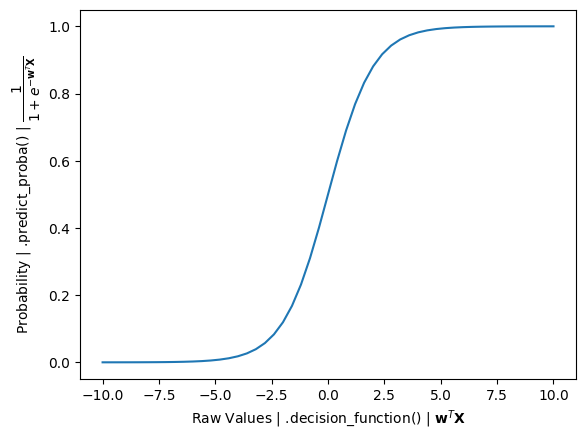

In [129]:
import numpy as np


def sigmoid(z):
    return 1 / (1+ np.exp(-z))

z = np.linspace(-10, 10, 51)

plt.plot(z, sigmoid(z))
plt.xlabel("Raw Values | .decision_function() | $\mathbf{w}^T \mathbf{X}$")
plt.ylabel("Probability | .predict_proba() | $\dfrac{1}{1 + e^{-\mathbf{w}^T \mathbf{X}}}$")

In [130]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]
    
    return result

In [131]:
def logistic_regression(xi):
    return sigmoid(linear_regression(xi))

Both linear regression and logistic regression are **linear models** because of the dot product, which is a linear combination of $w$ and $x$.

## 3.10 [Training logistic regression with Scikit-Learn](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/10-training-log-reg.md)


In [132]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)
model.coef_[0].round(3)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([ 0.421, -0.171, -0.373, -0.078,  0.065, -0.109, -0.079, -0.043,
       -0.08 , -0.317,  0.303, -0.109,  0.   , -0.246,  0.12 ,  0.003,
        0.058, -0.109, -0.072,  0.238, -0.109, -0.252,  0.356,  0.127,
       -0.082, -0.031,  0.068, -0.078, -0.243,  0.203, -0.097, -0.109,
        0.083, -0.058, -0.109,  0.044,  0.194, -0.109, -0.208, -0.081,
        0.   ])

In [133]:
model.intercept_[0].round(3)

np.float64(-0.125)

There are the hard predictions (end result):

In [134]:
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], dtype=int8)

These are the soft predictions:

In [135]:
model.predict_proba(X_train)

array([[0.90304934, 0.09695066],
       [0.32576217, 0.67423783],
       [0.35241543, 0.64758457],
       ...,
       [0.48770545, 0.51229455],
       [0.96229264, 0.03770736],
       [0.29729868, 0.70270132]])

The first column is the probability of the negative class (not churning), the second column is the probability of the positive class (churning). The positive class is what we're interested in. They add up to 1.

In [136]:
model.predict_proba(X_train).sum(axis=1)

array([1., 1., 1., ..., 1., 1., 1.])

In [137]:
y_pred = model.predict_proba(X_val)[:, 1]

churn_decision = (y_pred >= 0.5)

In [138]:
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
9       0887-hjgar
11      2637-fkfsy
12      7228-omtpn
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 317, dtype: string

These would be the customers who we would send a promotional e-mail.

Let's check our accuracy:

In [139]:
(y_val == churn_decision.astype(int)).mean()

np.float64(0.8005677785663591)

Our accuracy is 80%, which means we made a correct prediction for 4 out of 5 customers.

## 3.11 [Model interpretation](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/11-log-reg-interpretation.md)


We can take a look at the coefficient for each feature as follows:

In [140]:
dict(zip(dv.feature_names_, model.coef_[0].round(3).tolist()))

{'contract=month-to-month': 0.421,
 'contract=one_year': -0.171,
 'contract=two_year': -0.373,
 'dependents': -0.078,
 'deviceprotection=no': 0.065,
 'deviceprotection=no_internet_service': -0.109,
 'deviceprotection=yes': -0.079,
 'gender=female': -0.043,
 'gender=male': -0.08,
 'internetservice=dsl': -0.317,
 'internetservice=fiber_optic': 0.303,
 'internetservice=no': -0.109,
 'monthlycharges': 0.0,
 'multiplelines=no': -0.246,
 'multiplelines=no_phone_service': 0.12,
 'multiplelines=yes': 0.003,
 'onlinebackup=no': 0.058,
 'onlinebackup=no_internet_service': -0.109,
 'onlinebackup=yes': -0.072,
 'onlinesecurity=no': 0.238,
 'onlinesecurity=no_internet_service': -0.109,
 'onlinesecurity=yes': -0.252,
 'paperlessbilling': 0.356,
 'partner': 0.127,
 'paymentmethod=bank_transfer_(automatic)': -0.082,
 'paymentmethod=credit_card_(automatic)': -0.031,
 'paymentmethod=electronic_check': 0.068,
 'paymentmethod=mailed_check': -0.078,
 'phoneservice': -0.243,
 'seniorcitizen': 0.203,
 'strea

We will make a smaller model with a subset of features:

In [141]:
small = ["contract", "tenure", "monthlycharges"]

In [142]:
df_train[small].iloc[:10].to_dict(orient="records")

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month',
  'tenure': 5,
  'monthlycharges': 75.55000305175781},
 {'contract': 'month-to-month',
  'tenure': 5,
  'monthlycharges': 80.8499984741211},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.100000381469727},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month',
  'tenure': 1,
  'monthlycharges': 75.0999984741211},
 {'contract': 'month-to-month',
  'tenure': 1,
  'monthlycharges': 70.30000305175781},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month',
  'tenure': 6,
  'monthlycharges': 109.9000015258789}]

In [143]:
dict_train_small = df_train[small].to_dict(orient="records")
dict_val_small = df_val[small].to_dict(orient="records")

In [144]:
dv_small = DictVectorizer(sparse=False)
X_train_small = dv_small.fit_transform(dict_train_small)
X_val_small = dv_small.fit_transform(dict_val_small)

In [145]:
model_small = LogisticRegression()

model_small.fit(X_train_small, y_train)

y_pred = model_small.predict(X_val_small)

In [146]:
(y_pred == y_val).sum() / y_val.shape[0]

np.float64(0.7963094393186657)

Let's take a look at the coefficients again:

In [147]:
dict(zip(dv_small.feature_names_, model_small.coef_[0].round(3).tolist()))

{'contract=month-to-month': 0.971,
 'contract=one_year': -0.024,
 'contract=two_year': -0.948,
 'monthlycharges': 0.027,
 'tenure': -0.036}

Let's look at the bias term:

In [148]:
w0 = model_small.intercept_.round(3)

In [149]:
w = model_small.coef_[0].round(3)

Let's now try to interpret this. Let's first consider the bias term:

In [150]:
w0 + 0 * w[0] + 0 * w[1] + 0 * w[2] + 0 * w[3] + 0 * w[4]

array([-2.478])

The bias term is -2.478. When we put this in the sigmoid function, we get:

In [151]:
sigmoid(_)

array([0.07741493])

This is the probability of churn if we don't have any information other information available. But now let's make some assumptions:
- The customer has a month-to-month contract
- The customer has monthly charges of 50
- The customer has a tenure of 5 months:

In [152]:
w0 + 1 * w[0] + 0 * w[1] + 0 * w[2] + 50 * w[3] + 5 * w[4]

array([-0.337])

In [153]:
sigmoid(_)

array([0.4165384])

Now, the probability that the customer will churn is 42%. Let's double the tenure:

In [154]:
sigmoid(w0 + 1 * w[0] + 0 * w[1] + 0 * w[2] + 50 * w[3] + 10 * w[4])

array([0.373554])

The probability has gone down. The longer a customer has the contract, the less likely they are to churn.

For the one-hot encoded variables, there will always be one variable which is 'hot' (multiplied by 1), while the others will be 'cold (multiplied by 0).

## 3.12 [Using the model](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/12-using-log-reg.md)


We will take the big model with all the features, and train it on the full training data (including validation):

In [155]:
df_full_train_dict = df_full_train[categorical + numeric].to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(df_full_train_dict)

y_full_train = df_full_train.churn.values

In [156]:
X_full_train.shape

(5634, 41)

In [157]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [158]:
dicts_test = df_test[categorical + numeric].to_dict(orient="records")
X_test = dv.transform(dicts_test)

In [159]:
model.predict(X_test)
y_pred = model.predict_proba(X_test)[:, 1]

In [160]:
churn_decision = (y_pred >= 0.5)

In [161]:
(churn_decision == y_test).mean()

np.float64(0.8097941802696949)

Now that we have our model, imagine that we want to use it. How would we do that?

Let's say we take information from a 'new' customer:

In [162]:
customer = dicts_test[10]
customer

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 1,
 'dependents': 1,
 'phoneservice': 1,
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 1,
 'paymentmethod': 'mailed_check',
 'tenure': 32,
 'monthlycharges': 93.94999694824219,
 'totalcharges': 2861.449951171875}

We will use the DictVectorizer to transform this into a Numpy array:

In [163]:
X_small = dv.transform([customer])

In [164]:
model.predict_proba(X_small)[0, 1]

np.float64(0.41891456373683517)

This customer is not likely to churn, so we do nothing.

## 3.13 [Summary](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/13-summary.md)


No notes.

## 3.14 [Explore more](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/14-explore-more.md)


No notes.

## 3.15 [Homework](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/homework.md)

[Go to week_3_homework.ipynb](week_3_homework.ipynb)